## Apply  RFM Analysis and K-mean clustering
### In this section we will Using RFM and Cluster the customers with K-mean Clustering
- Calculate the Recency, Frequency and Monterey of each customer base on their past transection
- Calculate the RFM score scale 1-5 base on uantile-based binning
- Find Number of K based on 3 methods
- Selected the suitable number of K and cluster
- Insight from cluster provide the type and description of each customer

In [1]:
#import library and ignore warning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

In [2]:
#load the cvs file and check header
customers = pd.read_csv('../data/processed/online_retail_final.csv')

customers.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend,InvoiceYearMonth,InvoiceDateOnly,InvoiceDayOfWeek,InvoiceHour
0,536365,85123A,white hanging heart t-light holder,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,2010-12-01,Wednesday,8
1,536365,71053,white metal lantern,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12-01,Wednesday,8
2,536365,84406B,cream cupid hearts coat hanger,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,2010-12-01,Wednesday,8
3,536365,84029G,knitted union flag hot water bottle,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12-01,Wednesday,8
4,536365,84029E,red woolly hottie white heart.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12-01,Wednesday,8


In [3]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   InvoiceNo         392692 non-null  int64  
 1   StockCode         392692 non-null  object 
 2   Description       392692 non-null  object 
 3   Quantity          392692 non-null  int64  
 4   InvoiceDate       392692 non-null  object 
 5   UnitPrice         392692 non-null  float64
 6   CustomerID        392692 non-null  int64  
 7   Country           392692 non-null  object 
 8   TotalSpend        392692 non-null  float64
 9   InvoiceYearMonth  392692 non-null  object 
 10  InvoiceDateOnly   392692 non-null  object 
 11  InvoiceDayOfWeek  392692 non-null  object 
 12  InvoiceHour       392692 non-null  int64  
dtypes: float64(2), int64(4), object(7)
memory usage: 38.9+ MB


In [4]:
#convert datatypes in columns InvoiceDate
customers['InvoiceDate'] = pd.to_datetime(customers['InvoiceDate'], format='%Y-%m-%d %H:%M:%S')
customers.dtypes

InvoiceNo                    int64
StockCode                   object
Description                 object
Quantity                     int64
InvoiceDate         datetime64[ns]
UnitPrice                  float64
CustomerID                   int64
Country                     object
TotalSpend                 float64
InvoiceYearMonth            object
InvoiceDateOnly             object
InvoiceDayOfWeek            object
InvoiceHour                  int64
dtype: object

### Find the Reference date to calculate Recency

In [5]:
#references date
#in here we find the latest date in dataset by adding 1 as the latest date which mean that
#if the last purchase is 08-03-2026 then ref_date = 09-03-2026
ref_date = customers['InvoiceDate'].max() + pd.DateOffset(days=1)
ref_date

Timestamp('2011-12-10 12:50:00')

### Calculate RFM

In [6]:
#calculate and create a dataframe for Recently, Frequency, and Monetary

rfm_customer = customers.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (ref_date - x.max()).days, #recency
    'InvoiceNo': 'nunique', #frequency (count unique)
    'TotalSpend': 'sum' #monetary
}).reset_index()

# Rename columns
rfm_customer.rename(columns={'InvoiceDate':'Recency',
                    'InvoiceNo':'Frequency',
                    'TotalSpend':'Monetary'}, inplace=True)

rfm_customer.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


### Check the distribution by describe

In [7]:
#check the distribution from 0, 25, 50 and 100
rfm_customer.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


### Plot Histogram and boxplot for RFM

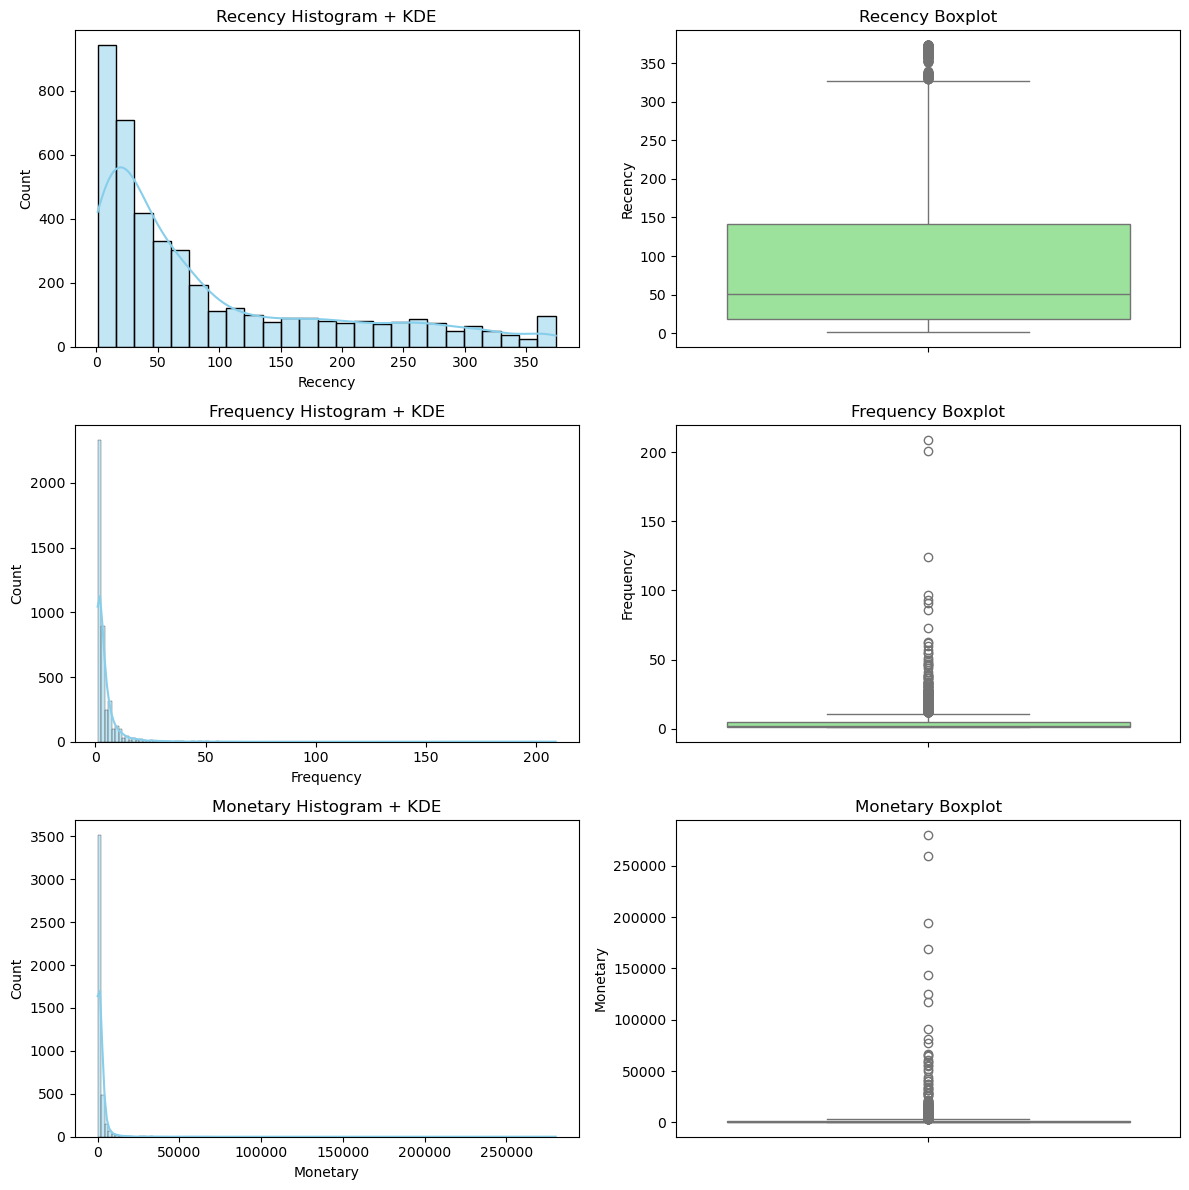

In [8]:
# Columns to plot
cols = ['Recency', 'Frequency', 'Monetary']

# Create figure with 3 rows x 2 columns
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for i, col in enumerate(cols):
    # Row index
    row = i
    
    # Histogram with KDE
    sns.histplot(data=rfm_customer, x=col, kde=True, ax=axes[row, 0], color='skyblue')
    axes[row, 0].set_title(f'{col} Histogram + KDE')
    
    # Boxplot
    sns.boxplot(data=rfm_customer, y=col, ax=axes[row, 1], color='lightgreen')
    axes[row, 1].set_title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

### Create Bin and RFM Score for cluster

In [9]:
#Bin the RFM values
recency_bins = [0, 20, 50, 150, 250, 400] #very recen, recen, moderate, olde recen, very old
frequency_bins = [0, 2, 3, 10, 50, 250] #low freq, moderate freq, regular, freq, very freq
monetary_bins = [0, 300, 700, 2000, 5000, 280210] #low, moderate, high, very high, extremely

In [10]:
#apply the score to each customers
#lower values the most recents purchase
rfm_customer['RScore'] = pd.cut(rfm_customer['Recency'], bins=recency_bins, labels=[5, 4, 3, 2, 1], right=False).astype(int)
#highest Frequency get more score
rfm_customer['FScore'] = pd.cut(rfm_customer['Frequency'], bins=frequency_bins, labels=[1, 2, 3, 4, 5], right=False).astype(int)
#spending alot got bettter score
rfm_customer['MScore'] = pd.cut(rfm_customer['Monetary'], bins=monetary_bins, labels=[1, 2, 3, 4, 5], right=False).astype(int)

In [11]:
#check the rfm_customer dataframe
rfm_customer.head()

,CustomerID,Recency,Frequency,Monetary,RScore,FScore,MScore
0,12346,326,1,77183.60,1,1,5
1,12347,2,7,4310.00,5,3,4
2,12348,75,4,1797.24,3,3,3
3,12349,19,1,1757.55,5,1,3
4,12350,310,1,334.40,1,1,2


### Apply K-Mean clustering with RFM Score

In [12]:
#create a new dataframe to use that RFM score for clustering with K-mean
rfm_kmeans = rfm_customer[['RScore', 'FScore', 'MScore']]
rfm_kmeans.head()

,RScore,FScore,MScore
0,1,1,5
1,5,3,4
2,3,3,3
3,5,1,3
4,1,1,2


### Find the K-cluster by 3 methods

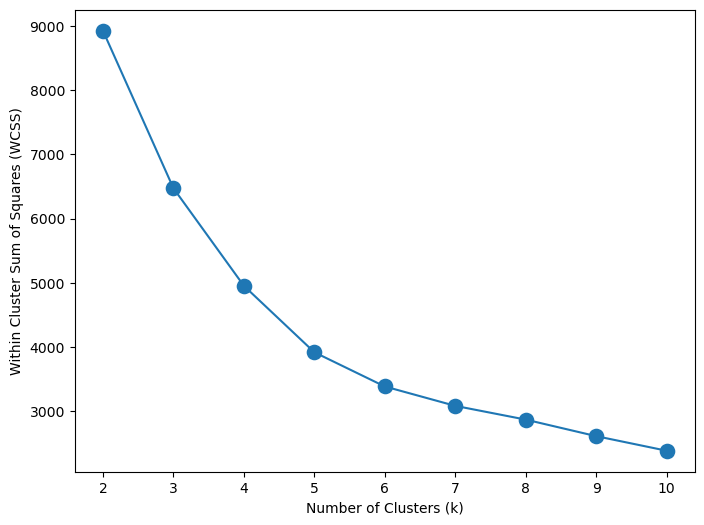

In [13]:
#calculate the k-cluster
wcss = []
for k in range(2, 11):
    km = KMeans(n_clusters = k, n_init = 25, random_state = 1234)
    km.fit(rfm_kmeans)
    wcss.append(km.inertia_)

wcss_series = pd.Series(wcss, index = range(2, 11))

plt.figure(figsize=(8, 6))
ax = sns.lineplot(y = wcss_series, x = wcss_series.index)
ax = sns.scatterplot(y = wcss_series, x = wcss_series.index, s = 150)
ax = ax.set(xlabel = 'Number of Clusters (k)', 
            ylabel = 'Within Cluster Sum of Squares (WCSS)')

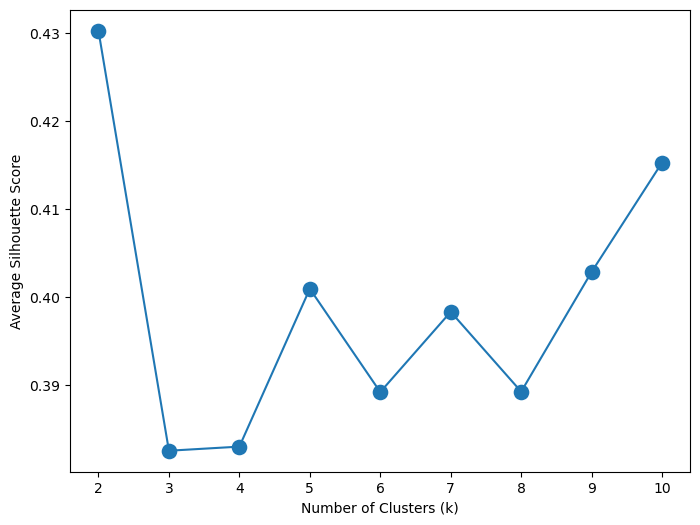

In [14]:
from sklearn.metrics import silhouette_score

silhouette = []
for k in range(2, 11):
    km = KMeans(n_clusters = k, n_init = 25, random_state = 1234)
    km.fit(rfm_kmeans)
    silhouette.append(silhouette_score(rfm_kmeans, km.labels_))

silhouette_series = pd.Series(silhouette, index = range(2, 11))

plt.figure(figsize=(8, 6))
ax = sns.lineplot(y = silhouette_series, x = silhouette_series.index)
ax = sns.scatterplot(y = silhouette_series, x = silhouette_series.index, s = 150)
ax = ax.set(xlabel = 'Number of Clusters (k)', 
            ylabel = 'Average Silhouette Score')

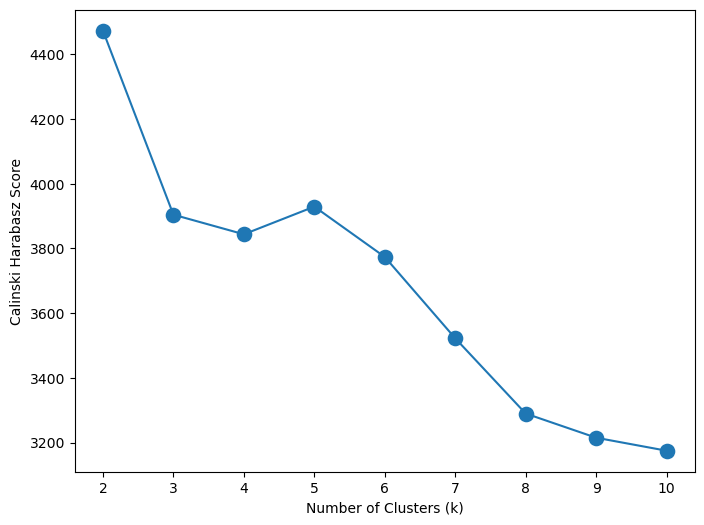

In [15]:
from sklearn.metrics import calinski_harabasz_score

calinski = []
for k in range(2, 11):
    km = KMeans(n_clusters = k, n_init = 25, random_state = 1234)
    km.fit(rfm_kmeans)
    calinski.append(calinski_harabasz_score(rfm_kmeans, km.labels_))

calinski_series = pd.Series(calinski, index = range(2, 11))

plt.figure(figsize=(8, 6))
ax = sns.lineplot(y = calinski_series, x = calinski_series.index)
ax = sns.scatterplot(y = calinski_series, x = calinski_series.index, s = 150)
ax = ax.set(xlabel = 'Number of Clusters (k)', 
            ylabel = 'Calinski Harabasz Score')

### Justify the n_clusters = 5
### To determine the optimal number of clusters, three evaluation methods were used:
- Elbow Method (WCSS)
- Silhouette Score
- Calinski–Harabasz Index
### Based on the results from these three metrics, K=5 was selected as the optimal number of clusters.
- The Elbow Method shows a noticeable bend around K = 5, where the reduction in WCSS begins to slow down.
- The Silhouette Score shows a relatively strong clustering structure around K = 5 compared to nearby values.
- The Calinski–Harabasz Index also indicates a reasonable balance of cluster separation and compactness near K = 5.

### Cluster the customer into 5 group

In [16]:
#we chose N_clusters = 5
km = KMeans(n_clusters = 5, n_init = 25, random_state = 1234)
km.fit(rfm_kmeans)

,n_clusters,5
,init,'k-means++'
,n_init,25
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,1234
,copy_x,True
,algorithm,'lloyd'


In [17]:
cluster_centers = pd.DataFrame(km.cluster_centers_, columns = ['RScore', 'FScore', 'MScore'])
cluster_centers.head()

,RScore,FScore,MScore
0,4.587729,2.792250,2.727664
1,1.456887,1.247480,1.518477
2,2.758273,2.769784,3.069065
3,3.584769,1.305530,1.581142
4,4.660167,3.519499,4.369081


In [18]:
print(rfm_kmeans.columns)

Index(['RScore', 'FScore', 'MScore'], dtype='object')


### Apply group cluster into each customer in rfm_customer dataframe

In [19]:
#apply cluster into each customer
rfm_customer['Cluster'] = km.labels_.tolist()
rfm_customer.head(10)

,CustomerID,Recency,Frequency,Monetary,RScore,FScore,MScore,Cluster
0,12346,326,1,77183.60,1,1,5,2
1,12347,2,7,4310.00,5,3,4,4
2,12348,75,4,1797.24,3,3,3,2
3,12349,19,1,1757.55,5,1,3,0
4,12350,310,1,334.40,1,1,2,1
5,12352,36,8,2506.04,4,3,4,4
6,12353,204,1,89.00,2,1,1,1
7,12354,232,1,1079.40,2,1,3,1
8,12355,214,1,459.40,2,1,2,1
9,12356,23,3,2811.43,4,3,4,4


### Plot the 3D and Pairplot distribution for Cluster

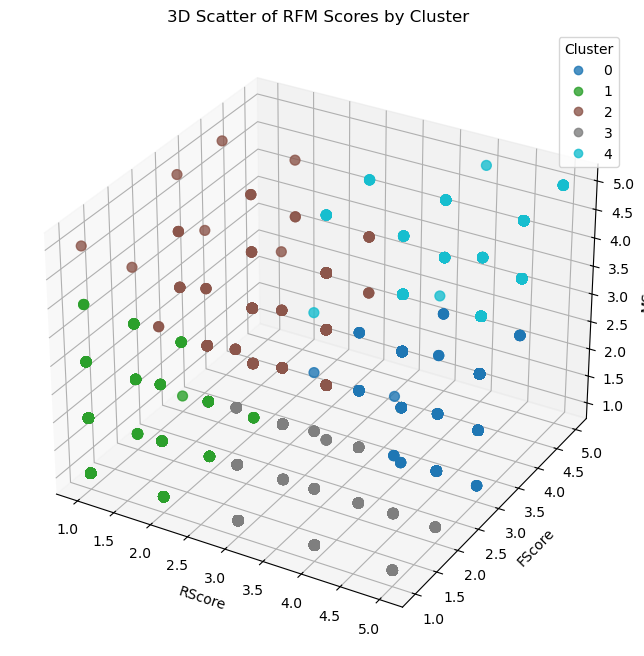

In [20]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    rfm_customer['RScore'],
    rfm_customer['FScore'],
    rfm_customer['MScore'],
    c=rfm_customer['Cluster'],  # your 5 cluster labels
    cmap='tab10',
    s=50,
    alpha=0.8
)

ax.set_xlabel('RScore')
ax.set_ylabel('FScore')
ax.set_zlabel('MScore')
plt.title('3D Scatter of RFM Scores by Cluster')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.show()

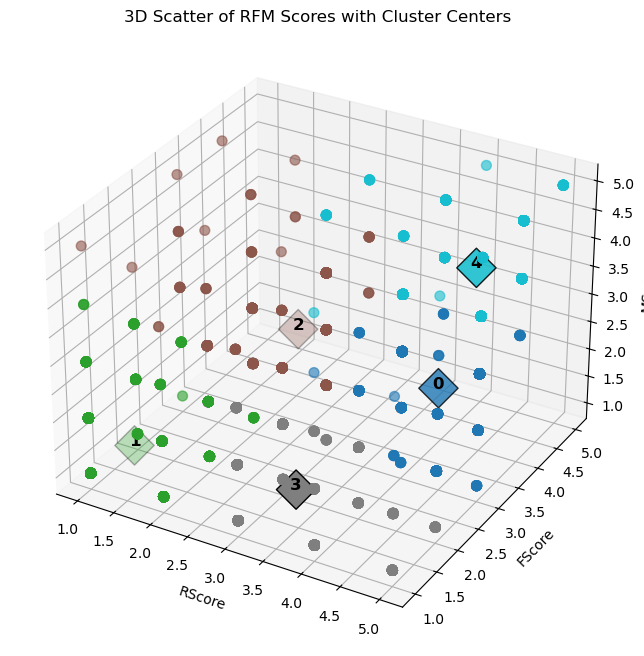

In [21]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Calculate cluster centers (means)
cluster_centers = rfm_customer.groupby('Cluster')[['RScore','FScore','MScore']].mean().reset_index()

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Plot customer points
scatter = ax.scatter(
    rfm_customer['RScore'],
    rfm_customer['FScore'],
    rfm_customer['MScore'],
    c=rfm_customer['Cluster'],
    cmap='tab10',
    s=50,
    alpha=0.6
)

# Plot cluster centers
ax.scatter(
    cluster_centers['RScore'],
    cluster_centers['FScore'],
    cluster_centers['MScore'],
    c=cluster_centers['Cluster'],
    cmap='tab10',
    s=400,
    marker='D',
    edgecolor='black'
)

# Add cluster labels (0–4)
for i in range(len(cluster_centers)):
    ax.text(
        cluster_centers['RScore'][i],
        cluster_centers['FScore'][i],
        cluster_centers['MScore'][i],
        str(cluster_centers['Cluster'][i]),
        color='black',
        fontsize=12,
        weight='bold',
        ha='center'
    )

ax.set_xlabel('RScore')
ax.set_ylabel('FScore')
ax.set_zlabel('MScore')

plt.title('3D Scatter of RFM Scores with Cluster Centers')
plt.show()

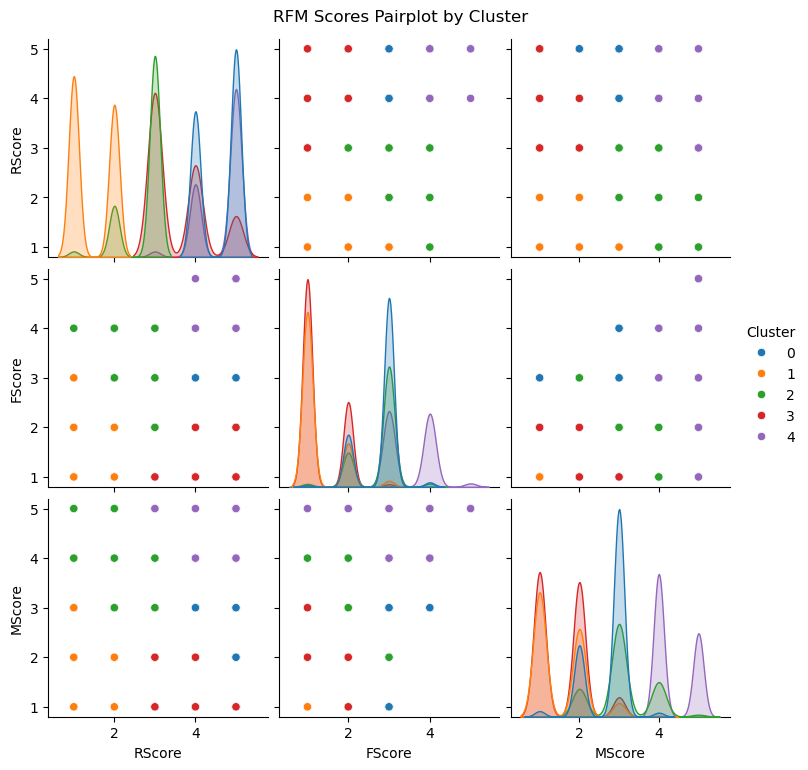

In [22]:
sns.pairplot(
    rfm_customer,
    vars=['RScore', 'FScore', 'MScore'],
    hue='Cluster',
    palette='tab10',
    diag_kind='kde',
    height=2.5
)
plt.suptitle('RFM Scores Pairplot by Cluster', y=1.02)
plt.show()

### Distribution of each cluster

In [23]:
#calculate the mean (average of each score)
rfm_customer.agg({
    'RScore': 'mean',
    'FScore': 'mean',
    'MScore': 'mean'
}).round(2).to_frame().T.assign(
    CustomerID_Count = rfm_customer.index.nunique())

,RScore,FScore,MScore,CustomerID_Count
0,3.41,2.21,2.51,4338


In [24]:
rfm_customer.head()

,CustomerID,Recency,Frequency,Monetary,RScore,FScore,MScore,Cluster
0,12346,326,1,77183.60,1,1,5,2
1,12347,2,7,4310.00,5,3,4,4
2,12348,75,4,1797.24,3,3,3,2
3,12349,19,1,1757.55,5,1,3,0
4,12350,310,1,334.40,1,1,2,1


In [25]:
#calculate the mean of each score base on each cluster

# Group by cluster and calculate mean R/F/M + count of customers
summary = rfm_customer.groupby('Cluster').agg({
    'RScore': 'mean',
    'FScore': 'mean',
    'MScore': 'mean',
    'CustomerID': 'nunique'   # number of customers in each cluster
}).reset_index().round(2)

#rename the column for clarity
summary.rename(columns={'CustomerID': 'NumCustomers'}, inplace=True)

print(summary)

   Cluster  RScore  FScore  MScore  NumCustomers
0        0    4.59    2.79    2.73           929
1        1    1.46    1.25    1.52           893
2        2    2.76    2.77    3.07           695
3        3    3.58    1.31    1.58          1103
4        4    4.66    3.52    4.37           718


In [26]:
#check discribe of each score
rfm_customer.groupby('Cluster')[['RScore', 'FScore', 'MScore']].describe().T

Cluster                0           1           2            3           4
RScore count  929.000000  893.000000  695.000000  1103.000000  718.000000
       mean     4.587729    1.456887    2.758273     3.584769    4.660167
       std      0.492509    0.498417    0.476221     0.720345    0.518931
       min      4.000000    1.000000    1.000000     3.000000    3.000000
       25%      4.000000    1.000000    3.000000     3.000000    4.000000
       50%      5.000000    1.000000    3.000000     3.000000    5.000000
       75%      5.000000    2.000000    3.000000     4.000000    5.000000
       max      5.000000    2.000000    3.000000     5.000000    5.000000
FScore count  929.000000  893.000000  695.000000  1103.000000  718.000000
       mean     2.792250    1.247480    2.769784     1.305530    3.519499
       std      0.465287    0.490157    0.505254     0.480128    0.552952
       min      1.000000    1.000000    1.000000     1.000000    1.000000
       25%      3.000000    1.000000    3.000000     1.000000    3.000000
       50%      3.000000    1.000000    3.000000     1.000000    4.000000
       75%      3.000000    1.000000    3.000000     2.000000    4.000000
       max      4.000000    3.000000    4.000000     3.000000    5.000000
MScore count  929.000000  893.000000  695.000000  1103.000000  718.000000
       mean     2.727664    1.518477    3.069065     1.581142    4.369081
       std      0.514969    0.625455    0.666926     0.611807    0.482892
       min      1.000000    1.000000    2.000000     1.000000    4.000000
       25%      2.000000    1.000000    3.000000     1.000000    4.000000
       50%      3.000000    1.000000    3.000000     2.000000    4.000000
       75%      3.000000    2.000000    3.000000     2.000000    5.000000
       max      4.000000    4.000000    5.000000     3.000000    5.000000

### Interpretation of each clusters

In [27]:
#add the description meaning of each cluster
cluster_desc = {
    0: 'Very recent customers with moderate purchase frequency and spending',
    1: 'Old customers with very low frequency and low spending (inactive/lost)',
    2: 'Moderately recent customers with good spending but average frequency',
    3: 'Recent customers with very low frequency and spending (one-time or disengaging)',
    4: 'Highly valuable customers: very recent, frequent, and high spending'
}

customer_type = {
    0: 'Active',
    1: 'Inactive',
    2: 'High Spenders',
    3: 'New/At Risk',
    4: 'VIP'
}

rfm_customer['Description'] = rfm_customer['Cluster'].map(cluster_desc)
rfm_customer['Type'] = rfm_customer['Cluster'].map(customer_type)
rfm_customer.head()

,CustomerID,Recency,Frequency,Monetary,RScore,FScore,MScore,Cluster,Description,Type
0,12346,326,1,77183.60,1,1,5,2,Moderately recent customers with good spending...,High Spenders
1,12347,2,7,4310.00,5,3,4,4,"Highly valuable customers: very recent, freque...",VIP
2,12348,75,4,1797.24,3,3,3,2,Moderately recent customers with good spending...,High Spenders
3,12349,19,1,1757.55,5,1,3,0,Very recent customers with moderate purchase f...,Active
4,12350,310,1,334.40,1,1,2,1,Old customers with very low frequency and low ...,Inactive


In [28]:
#plot each cluster infor again
# Group by cluster and calculate mean R/F/M + count of customers

summary = rfm_customer.groupby('Cluster').agg({
    'RScore': 'mean',
    'FScore': 'mean',
    'MScore': 'mean',
    'CustomerID': 'nunique',   # number of customers in each cluster
    'Description': 'first', #text
    'Type': 'first' #text
}).reset_index().round(2)

#rename the column for clarity
summary.rename(columns={'CustomerID': 'NumCustomers'}, inplace=True)

summary

,Cluster,RScore,FScore,MScore,NumCustomers,Description,Type
0,0,4.59,2.79,2.73,929,Very recent customers with moderate purchase f...,Active
1,1,1.46,1.25,1.52,893,Old customers with very low frequency and low ...,Inactive
2,2,2.76,2.77,3.07,695,Moderately recent customers with good spending...,High Spenders
3,3,3.58,1.31,1.58,1103,Recent customers with very low frequency and s...,New/At Risk
4,4,4.66,3.52,4.37,718,"Highly valuable customers: very recent, freque...",VIP


### plot bar graph compare each cluster for R, F, M Score

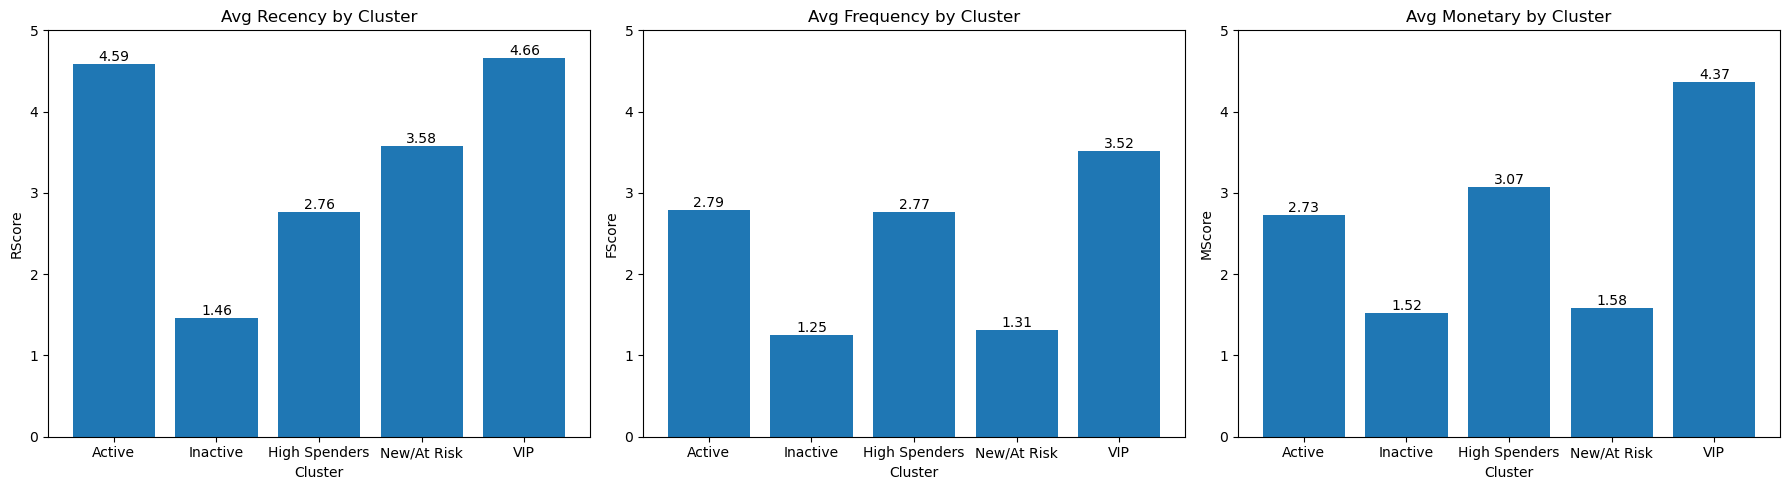

In [29]:
#plot bar graph compare each cluster for R, F, M Score

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency
bars0 = axes[0].bar(summary['Type'], summary['RScore'])
axes[0].set_title('Avg Recency by Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('RScore')
axes[0].set_ylim(0, 5)
axes[0].bar_label(bars0, fmt='%.2f', fontsize=10)

# Frequency
bars1 = axes[1].bar(summary['Type'], summary['FScore'])
axes[1].set_title('Avg Frequency by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('FScore')
axes[1].set_ylim(0, 5)
axes[1].bar_label(bars1, fmt='%.2f', fontsize=10)

# Monetary
bars2 = axes[2].bar(summary['Type'], summary['MScore'])
axes[2].set_title('Avg Monetary by Cluster')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('MScore')
axes[2].set_ylim(0, 5)
axes[2].bar_label(bars2, fmt='%.2f', fontsize=10)

plt.tight_layout()
plt.show()

### Customers per cluster

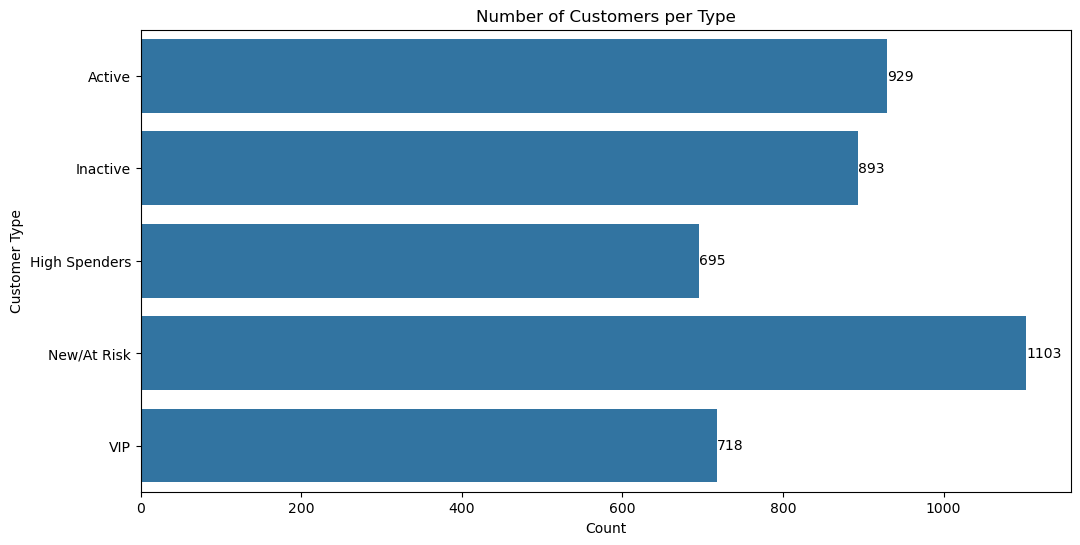

In [30]:
#count the customer per type
#plot the bar graph for Monetary average

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=summary,
    x='NumCustomers',    
    y='Type',      
)

# Add labels
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title('Number of Customers per Type')
plt.xlabel('Count')
plt.ylabel('Customer Type')

plt.show()

In [31]:
#check some of dataset rfm_customer
rfm_customer.sample(10)

,CustomerID,Recency,Frequency,Monetary,RScore,FScore,MScore,Cluster,Description,Type
1696,14656,169,2,291.05,2,2,1,1,Old customers with very low frequency and low ...,Inactive
1879,14911,1,201,143711.17,5,5,5,4,"Highly valuable customers: very recent, freque...",VIP
118,12493,166,2,433.74,2,2,2,1,Old customers with very low frequency and low ...,Inactive
2871,16255,17,8,2619.91,5,3,4,4,"Highly valuable customers: very recent, freque...",VIP
2961,16383,75,2,643.76,3,2,2,3,Recent customers with very low frequency and s...,New/At Risk
106,12477,23,6,13219.74,4,3,5,4,"Highly valuable customers: very recent, freque...",VIP
1001,13703,318,1,99.50,1,1,1,1,Old customers with very low frequency and low ...,Inactive
3858,17630,170,2,503.60,2,2,2,1,Old customers with very low frequency and low ...,Inactive
2959,16379,4,4,2157.40,5,3,4,4,"Highly valuable customers: very recent, freque...",VIP
2290,15465,20,18,7354.62,4,4,5,4,"Highly valuable customers: very recent, freque...",VIP


In [32]:
#load data into csv file
#save dataset after do Clustering
rfm_customer.to_csv("../data/cluster/online_retail_cluster.csv", index=False)